<a href="https://colab.research.google.com/github/kthanikonda/Privacy-Aware-Computing/blob/main/Privacy_Doc-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
! pip install textstat swifter

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for swifter: filename=swifter-1.4.0-py3-none-any.whl size=16507 sha256=6d9c6fde95961526b4190825cd3b92df8c9ff7b0242245abfa8267c143eb8bdf
  Stored in directory: /root/.cache/pip/wheels/ef/7f/bd/9bed48f078f3ee1fa75e0b29b6e0335ce1cb03a38d3443b3a3
Successfully built swifter


In [7]:
import nltk
import spacy
import numpy as np
import textstat
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords, wordnet as wn
from nltk import pos_tag
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from wordcloud import WordCloud
from textblob import TextBlob
from google.colab import files
import hashlib
from numpy.random import laplace
import swifter
import multiprocessing

#  STEP 1: File Upload & Reading
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f" Uploaded file: {filename}")
df_squad = pd.read_excel(filename, engine='openpyxl')
df_squad.head()


Saving Squad.xlsx to Squad.xlsx
 Uploaded file: Squad.xlsx


,question
0,To whom did the Virgin Mary allegedly appear i...
1,What is in front of the Notre Dame Main Building?
2,The Basilica of the Sacred heart at Notre Dame...
3,What is the Grotto at Notre Dame?
4,What sits on top of the Main Building at Notre...


In [8]:
#  STEP 2: Download NLTK Resources
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

# Load NLP & Stopwords
nlp = spacy.load("en_core_web_sm")
stop_words = set(stopwords.words("english"))


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


In [12]:
import pandas as pd
import spacy
import random
import nltk
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from IPython.display import display

nltk.download('averaged_perceptron_tagger_eng')

# Named Entity Redaction with Context-Aware Masking
def replace_named_entities(text):
    entity_replacements = {
        "PERSON": ["A Famous Figure", "A Renowned Individual"],
        "ORG": ["A Well-known Organization", "A Reputed Institution"],
        "GPE": ["A Global Region", "An International Place"],
        "DATE": ["Recently", "A Few Years Ago"],
        "TIME": ["Earlier Today", "Some Hours Ago"]
    }

    doc = nlp(text)
    entity_map = {}
    new_text = text

    for ent in doc.ents:
        if ent.label_ in entity_replacements:
            if ent.text not in entity_map:
                entity_map[ent.text] = random.choice(entity_replacements[ent.label_])

            # Replace only once per sentence to maintain readability
            new_text = new_text.replace(ent.text, entity_map[ent.text], 1)

    # If no entities found, replace proper nouns (NNP)
    if new_text == text:
        words = word_tokenize(text)
        tagged_words = pos_tag(words)
        for i, (word, tag) in enumerate(tagged_words):
            if tag == "NNP":
                words[i] = random.choice(["A Historic Landmark", "A Significant Place"])
                break
        new_text = " ".join(words)

    return new_text

df_squad["sanitized_question"] = df_squad["question"].astype(str).apply(replace_named_entities)


# Display First 5 Rows in Desired Format
print("\n Named Entity Redaction Completed\n")
for i in range(min(5, len(df_squad))):  # Show first 5 rows
    original = df_squad.loc[i, "question"]
    sanitized = df_squad.loc[i, "sanitized_question"]

    print(f"Original Question: {original}")
    print(f"Sanitized Question: {sanitized}")
    print("-" * 80)

#  Save Processed Data
sanitized_file_path = "sanitized_squad.csv"
df_squad.to_csv(sanitized_file_path, index=False)
print(f" Named Entity Redacted Data saved as: {sanitized_file_path}")


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.



 Named Entity Redaction Completed

Original Question: To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?
Sanitized Question: To whom did the Virgin Mary allegedly appear in A Few Years Ago in A Famous Figure?
--------------------------------------------------------------------------------
Original Question: What is in front of the Notre Dame Main Building?
Sanitized Question: What is in front of the A Historic Landmark Dame Main Building ?
--------------------------------------------------------------------------------
Original Question: The Basilica of the Sacred heart at Notre Dame is beside to which structure?
Sanitized Question: The Basilica of the A Renowned Individual heart at Notre Dame is beside to which structure?
--------------------------------------------------------------------------------
Original Question: What is the Grotto at Notre Dame?
Sanitized Question: What is the A Historic Landmark at Notre Dame ?
-------------------------------------------

In [13]:
# Named Entity Redaction with Meaning Preservation
def replace_named_entities(text):
    entity_replacements = {
        "PERSON": ["A Historical Figure", "A Renowned Individual"],
        "ORG": ["An Established Organization", "A Well-Known Institution"],
        "GPE": ["A Notable Region", "A Recognized Location"],
        "DATE": ["A Certain Year", "Some Time Ago"],
        "TIME": ["Earlier Today", "A Short While Ago"],
        "FAC": ["A Recognized Building", "A Known Monument"],
        "LOC": ["A Specific Location", "A Known Area"]
    }

    doc = nlp(text)
    new_text = text
    entity_map = {}

    for ent in doc.ents:
        if ent.label_ in entity_replacements:
            replacement = random.choice(entity_replacements[ent.label_])
            if ent.text not in entity_map:
                entity_map[ent.text] = replacement

            new_text = new_text.replace(ent.text, entity_map[ent.text], 1)

    return new_text

#  Apply Named Entity Redaction
df_squad["sanitized_question"] = df_squad["question"].astype(str).apply(replace_named_entities)

#  Display First 5 Rows
print("\n Named Entity Redaction Completed\n")
for i in range(min(5, len(df_squad))):
    original = df_squad.loc[i, "question"]
    sanitized = df_squad.loc[i, "sanitized_question"]

    print(f"Original Question: {original}")
    print(f"Sanitized Question: {sanitized}")
    print("-" * 80)

#  Save Processed Data
sanitized_file_path = "sanitized_squad_fixed.csv"
df_squad.to_csv(sanitized_file_path, index=False)
print(f" Named Entity Redacted Data saved as: {sanitized_file_path}")



 Named Entity Redaction Completed

Original Question: To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?
Sanitized Question: To whom did A Known Monument allegedly appear in Some Time Ago in A Renowned Individual?
--------------------------------------------------------------------------------
Original Question: What is in front of the Notre Dame Main Building?
Sanitized Question: What is in front of A Recognized Building?
--------------------------------------------------------------------------------
Original Question: The Basilica of the Sacred heart at Notre Dame is beside to which structure?
Sanitized Question: The Basilica of the A Renowned Individual heart at A Known Monument is beside to which structure?
--------------------------------------------------------------------------------
Original Question: What is the Grotto at Notre Dame?
Sanitized Question: What is the Grotto at A Known Monument?
--------------------------------------------------------------

In [14]:
import spacy
import os
os.system("python -m spacy download en_core_web_md")  # Install in runtime
nlp = spacy.load("en_core_web_md")  # Load after installation


In [15]:
#  STEP 4: DP Perturbation with Exponential Mechanism
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'): return wn.ADJ
    elif treebank_tag.startswith('V'): return wn.VERB
    elif treebank_tag.startswith('N'): return wn.NOUN
    elif treebank_tag.startswith('R'): return wn.ADV
    else: return None

def dp_text_perturbation(text, prob=0.3, epsilon=1.0):
    words = word_tokenize(text)
    pos_tags = pos_tag(words)
    perturbed_text = []
    for word, tag in pos_tags:
        if random.random() < prob:
            wn_pos = get_wordnet_pos(tag)
            synonyms = wn.synsets(word, pos=wn_pos) if wn_pos else wn.synsets(word)
            synonym_list = [lemma.name() for syn in synonyms for lemma in syn.lemmas() if "_" not in lemma.name()]
            synonym_list = list(set(synonym_list))  # Remove duplicates
            if synonym_list:
                scores = np.random.laplace(0, 1 / epsilon, len(synonym_list))
                probabilities = np.exp(epsilon * scores) / np.sum(np.exp(epsilon * scores))
                perturbed_text.append(np.random.choice(synonym_list, p=probabilities))
                continue
        perturbed_text.append(word)
    return ' '.join(perturbed_text)

df_squad["dp_perturbation"] = df_squad["sanitized_question"].apply(lambda x: dp_text_perturbation(x, epsilon=1.0))

# Display First 5 Rows
print("\n DP Perturbation with Exponential Mechanism Applied\n")
for i in range(min(5, len(df_squad))):
    original = df_squad.loc[i, "question"]
    sanitized = df_squad.loc[i, "sanitized_question"]
    perturbed = df_squad.loc[i, "dp_perturbation"]

    print(f"Original Question: {original}")
    print(f"Sanitized Question: {sanitized}")
    print(f"DP Perturbed Question: {perturbed}")
    print("-" * 80)

# Save Processed Data
dp_perturb_file_path = "dp_squad_final_fixed.csv"
df_squad.to_csv(dp_perturb_file_path, index=False)
print(f" DP Perturbation with Exponential Mechanism Data saved as: {dp_perturb_file_path}")



 DP Perturbation with Exponential Mechanism Applied

Original Question: To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?
Sanitized Question: To whom did A Known Monument allegedly appear in Some Time Ago in A Renowned Individual?
DP Perturbed Question: To whom did a Known Monument allegedly appear in Some Time Ago in A Renowned person ?
--------------------------------------------------------------------------------
Original Question: What is in front of the Notre Dame Main Building?
Sanitized Question: What is in front of A Recognized Building?
DP Perturbed Question: What is in front of A Recognized Building ?
--------------------------------------------------------------------------------
Original Question: The Basilica of the Sacred heart at Notre Dame is beside to which structure?
Sanitized Question: The Basilica of the A Renowned Individual heart at A Known Monument is beside to which structure?
DP Perturbed Question: The Basilica of the A Renowned Individu

In [16]:
# Train Word2Vec Model on DP-Perturbed Text
sentences = [text.split() for text in df_squad['dp_perturbation']]
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=multiprocessing.cpu_count())

# Compute Mean Embedding for OOV Words
mean_embedding = np.mean(w2v_model.wv.vectors, axis=0)

# Function to Get Sentence Embedding with Minimal Laplace Noise
def get_sentence_embedding(text, epsilon=1.5):
    words = text.split()
    word_vectors = [w2v_model.wv[word] if word in w2v_model.wv else mean_embedding for word in words]
    embedding = np.mean(word_vectors, axis=0) if word_vectors else mean_embedding
    noise = laplace(0, 1 / epsilon, embedding.shape)  # **Reduce noise for consistency**
    return embedding + noise

# Apply Embeddings
df_squad['original_embedding'] = df_squad['sanitized_question'].swifter.apply(lambda x: get_sentence_embedding(x, epsilon=1.5))
df_squad['dp_embedding'] = df_squad['dp_perturbation'].swifter.apply(lambda x: get_sentence_embedding(x, epsilon=1.5))

# Display First 5 Rows in Correct Format
print("\n **Sample Sentences: Word Embeddings Before and After DP Perturbation**\n")
for i in range(min(5, len(df_squad))):
    original = df_squad.loc[i, "sanitized_question"]
    perturbed = df_squad.loc[i, "dp_perturbation"]
    original_embedding = df_squad.loc[i, "original_embedding"][:5]  # First 5 dimensions
    dp_embedding = df_squad.loc[i, "dp_embedding"][:5]  # First 5 dimensions

    print(f"Original Sentence: {original}")
    print(f"Perturbed Sentence: {perturbed}")
    print(f"Original Embedding (First 5 Dimensions): {np.round(original_embedding, 8)}")
    print(f"DP-Perturbed Embedding (First 5 Dimensions): {np.round(dp_embedding, 8)}")
    print("-" * 80)

# Save Processed Data
sanitized_file_path = "sanitized_squad-2.csv"
df_squad.to_csv(sanitized_file_path, index=False)
print(f"Word Embeddings with Laplace Noise Injection Data saved as: {sanitized_file_path}")

dp_perturb_file_path = "dp_squad_final_fixed.csv"
df_squad.to_csv(dp_perturb_file_path, index=False)
print(f"DP Perturbation with Exponential Mechanism Data saved as: {dp_perturb_file_path}")

Pandas Apply:   0%|          | 0/2000 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2000 [00:00<?, ?it/s]


 **Sample Sentences: Word Embeddings Before and After DP Perturbation**

Original Sentence: To whom did A Known Monument allegedly appear in Some Time Ago in A Renowned Individual?
Perturbed Sentence: To whom did a Known Monument allegedly appear in Some Time Ago in A Renowned person ?
Original Embedding (First 5 Dimensions): [ 4.25355747  0.85151161  1.13976218 -0.02847491 -0.70373592]
DP-Perturbed Embedding (First 5 Dimensions): [-0.24386068 -0.30367808 -3.14567192 -0.25296868 -0.06569726]
--------------------------------------------------------------------------------
Original Sentence: What is in front of A Recognized Building?
Perturbed Sentence: What is in front of A Recognized Building ?
Original Embedding (First 5 Dimensions): [ 0.92434656  0.67402731 -0.34662522  0.59194925  1.29109676]
DP-Perturbed Embedding (First 5 Dimensions): [-0.42333645  1.07031209 -2.37429539 -0.41783241 -0.203279  ]
--------------------------------------------------------------------------------
Orig

In [17]:
# STEP 8: Sentiment Analysis & Deception Score Calculation
def calculate_sentiment(text):
    return TextBlob(text).sentiment.polarity if text.strip() else 0.0

def calculate_deception_score(text):
    vague_words = ["may", "might", "could", "possibly", "sometimes", "often"]
    vague_word_count = sum(text.lower().count(word) for word in vague_words)
    clarity_score = textstat.flesch_reading_ease(text)
    return (100 - clarity_score) * 0.7 + (vague_word_count * 5) * 0.3

df_squad["sentiment_score"] = df_squad["question"].apply(calculate_sentiment)
df_squad["dp_sentiment_score"] = df_squad["dp_perturbation"].apply(calculate_sentiment)
df_squad["deception_score"] = df_squad["question"].apply(calculate_deception_score)
df_squad["dp_deception_score"] = df_squad["dp_perturbation"].apply(calculate_deception_score)

# Display First 5 Rows of Sentiment & Deception Score
import pandas as pd
from IPython.display import display

print(" Sentiment & Deception Score Calculated")
display(df_squad.head(5))  # Fixed for Google Colab/Jupyter


🔹 Sentiment & Deception Score Calculated


,question,sanitized_question,dp_perturbation,original_embedding,dp_embedding,sentiment_score,dp_sentiment_score,deception_score,dp_deception_score
0,To whom did the Virgin Mary allegedly appear i...,To whom did A Known Monument allegedly appear ...,To whom did a Known Monument allegedly appear ...,"[4.2535574699795875, 0.8515116104639358, 1.139...","[-0.24386067607259398, -0.3036780805959257, -3...",-0.100000,-0.100000,23.282,31.332
1,What is in front of the Notre Dame Main Building?,What is in front of A Recognized Building?,What is in front of A Recognized Building ?,"[0.924346562517973, 0.6740273081278331, -0.346...","[-0.4233364464668097, 1.0703120866064717, -2.3...",0.166667,0.000000,3.381,13.804
2,The Basilica of the Sacred heart at Notre Dame...,The Basilica of the A Renowned Individual hear...,The Basilica of the A Renowned Individual core...,"[2.5201896611767847, -1.4216544610453306, -0.0...","[-0.6017307480100003, 0.5207479613970702, -0.1...",0.000000,0.000000,23.989,49.812
3,What is the Grotto at Notre Dame?,What is the Grotto at A Known Monument?,What live the Grotto at A Known Monument ?,"[-0.1965703428235106, -0.2577637296068309, -1....","[-0.46744853561935606, 1.9030779395661614, -0....",0.000000,0.136364,7.175,13.804
4,What sits on top of the Main Building at Notre...,What sits on top of A Recognized Building at A...,What sits on top of A Recognized Building at A...,"[-0.27964923660692054, -0.7672320171043912, -0...","[-0.15231593028163254, 0.3853957444984375, 0.3...",0.333333,0.500000,4.095,22.568


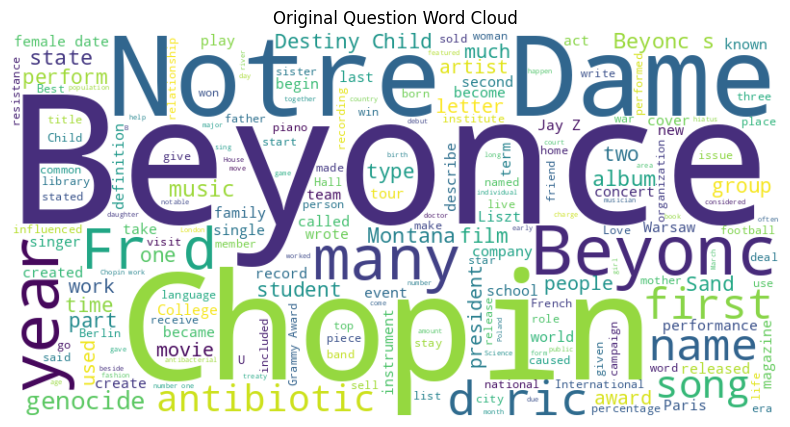

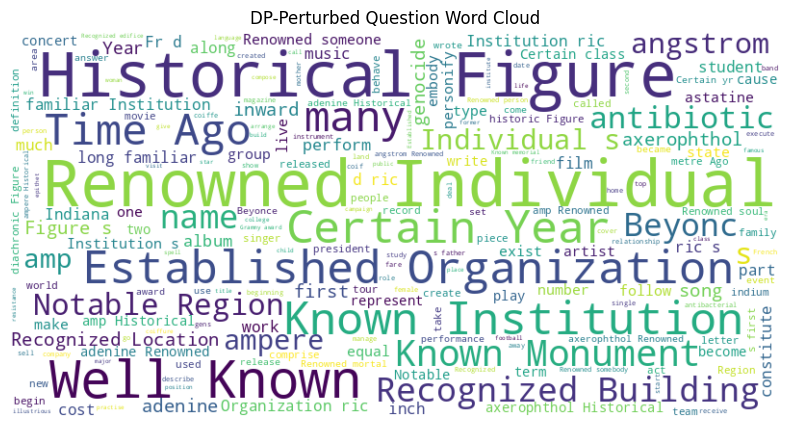

In [18]:
# STEP 6: Word Cloud
wordcloud_original = WordCloud(width=800, height=400, background_color='white').generate(" ".join(df_squad['question'].dropna()))
wordcloud_dp = WordCloud(width=800, height=400, background_color='white').generate(" ".join(df_squad['dp_perturbation'].dropna()))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_original, interpolation='bilinear')
plt.axis("off")
plt.title("Original Question Word Cloud")
plt.show()

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_dp, interpolation='bilinear')
plt.axis("off")
plt.title("DP-Perturbed Question Word Cloud")
plt.show()


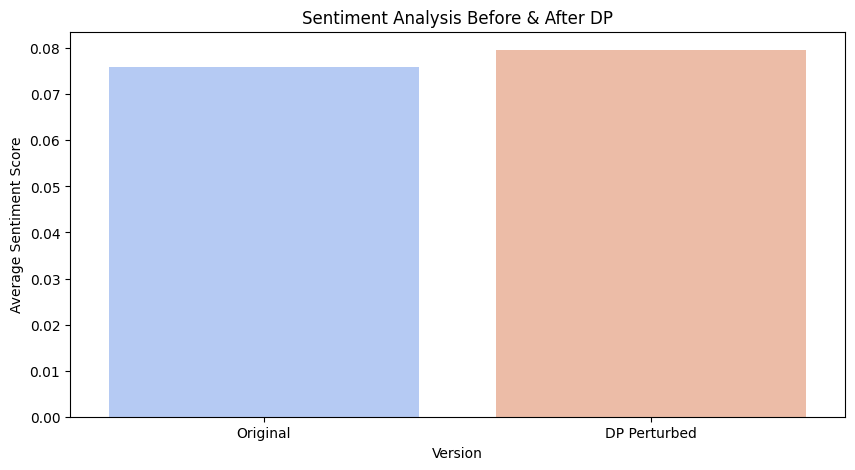

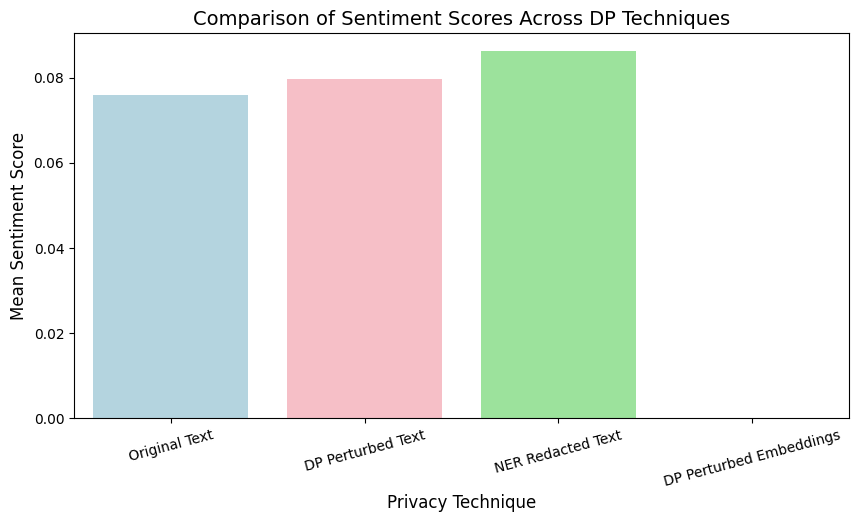

In [19]:
# **STEP 7: Bar Graph for Sentiment & Deception Score Changes**
plt.figure(figsize=(10, 5))
sns.barplot(x=["Original", "DP Perturbed"],
            y=[df_squad["sentiment_score"].mean(), df_squad["dp_sentiment_score"].mean()],
            palette='coolwarm')
plt.xlabel("Version")
plt.ylabel("Average Sentiment Score")
plt.title("Sentiment Analysis Before & After DP")
plt.show()

# Apply Sentiment Analysis with Fix for Embeddings
df_squad["sentiment_score"] = df_squad["question"].apply(calculate_sentiment)
df_squad["dp_sentiment_score"] = df_squad["dp_perturbation"].apply(calculate_sentiment)

# Additional DP Techniques
df_squad["ner_sentiment_score"] = df_squad["sanitized_question"].apply(calculate_sentiment)
df_squad["embedding_sentiment_score"] = df_squad["dp_embedding"].apply(lambda x: calculate_sentiment(" ".join(map(str, x))))

# Bar Chart for Sentiment Score Comparison
techniques = ["Original Text", "DP Perturbed Text", "NER Redacted Text", "DP Perturbed Embeddings"]
scores = [
    df_squad["sentiment_score"].mean(),
    df_squad["dp_sentiment_score"].mean(),
    df_squad["ner_sentiment_score"].mean(),
    df_squad["embedding_sentiment_score"].mean()
]

# Light color palette
light_palette = ["#ADD8E6", "#FFB6C1", "#90EE90", "#DDA0DD"]  # Light blue, pink, mint, lavender

plt.figure(figsize=(10, 5))
sns.barplot(x=techniques, y=scores, palette=light_palette)
plt.xlabel("Privacy Technique", fontsize=12)
plt.ylabel("Mean Sentiment Score", fontsize=12)
plt.title("Comparison of Sentiment Scores Across DP Techniques", fontsize=14)
plt.xticks(rotation=15)  # Rotate x-axis labels for readability
plt.show()


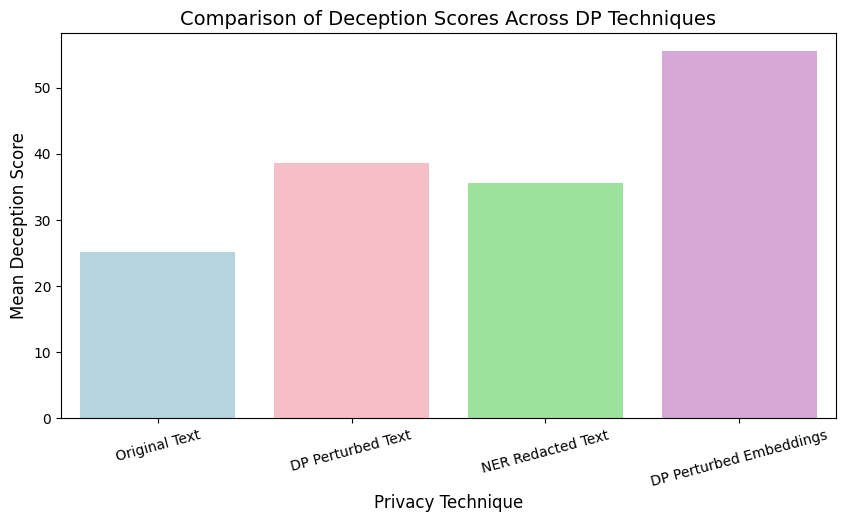

In [20]:
# Additional DP Techniques for Deception Score
df_squad["ner_deception_score"] = df_squad["sanitized_question"].apply(calculate_deception_score)
df_squad["embedding_deception_score"] = df_squad["dp_embedding"].apply(lambda x: calculate_deception_score(" ".join(map(str, x))))

# Bar Chart for Deception Score Comparison
techniques = ["Original Text", "DP Perturbed Text", "NER Redacted Text", "DP Perturbed Embeddings"]
scores = [
    df_squad["deception_score"].mean(),
    df_squad["dp_deception_score"].mean(),
    df_squad["ner_deception_score"].mean(),
    df_squad["embedding_deception_score"].mean()
]

# Light Color Palette for Better Visualization
light_palette = ["#ADD8E6", "#FFB6C1", "#90EE90", "#DDA0DD"]  # Light blue, pink, mint, lavender

plt.figure(figsize=(10, 5))
sns.barplot(x=techniques, y=scores, palette=light_palette)
plt.xlabel("Privacy Technique", fontsize=12)
plt.ylabel("Mean Deception Score", fontsize=12)
plt.title("Comparison of Deception Scores Across DP Techniques", fontsize=14)
plt.xticks(rotation=15)  # Rotate x-axis labels slightly for readability
plt.show()


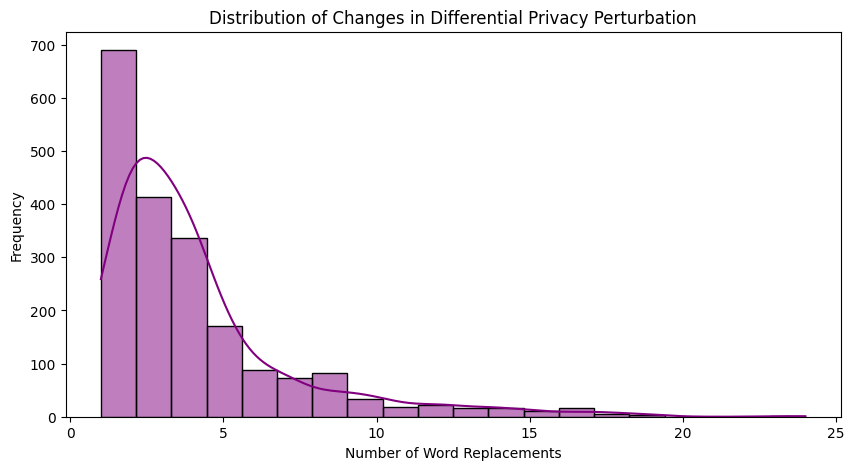

In [21]:
# **STEP 8: Histogram of Changes in Word Perturbation**
df_squad["num_changes"] = df_squad.apply(lambda row: sum(1 for o, p in zip(row["sanitized_question"].split(), row["dp_perturbation"].split()) if o != p), axis=1)

plt.figure(figsize=(10, 5))
sns.histplot(df_squad["num_changes"], bins=20, kde=True, color="purple")
plt.xlabel("Number of Word Replacements")
plt.ylabel("Frequency")
plt.title("Distribution of Changes in Differential Privacy Perturbation")
plt.show()

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


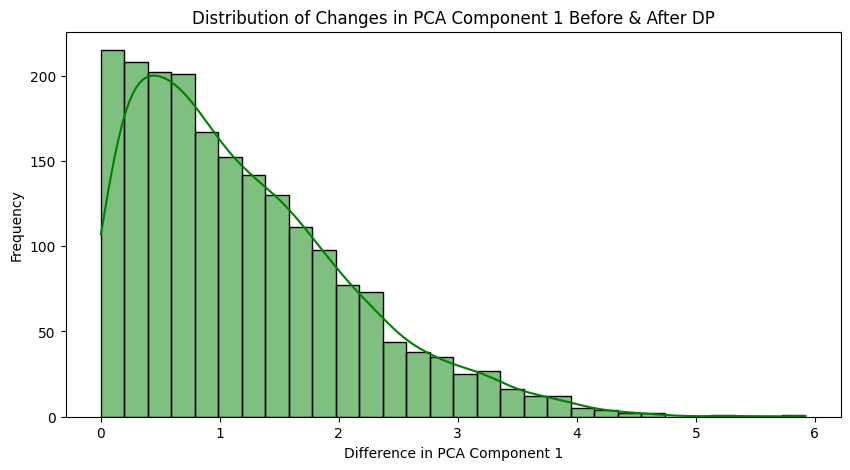

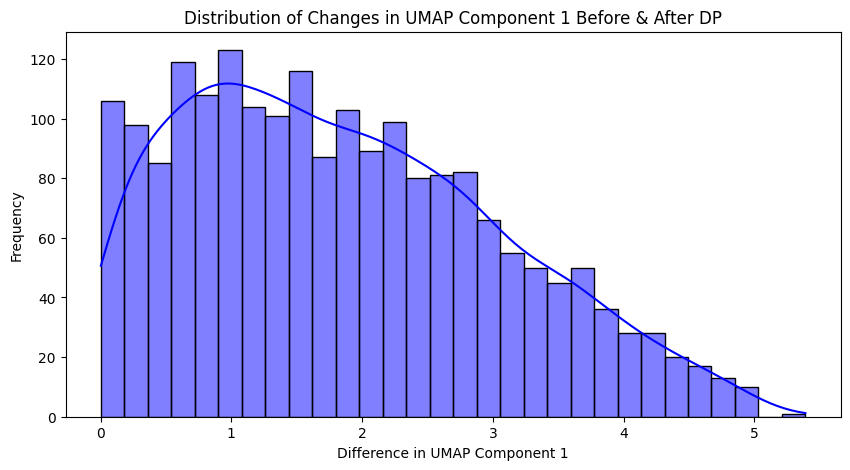

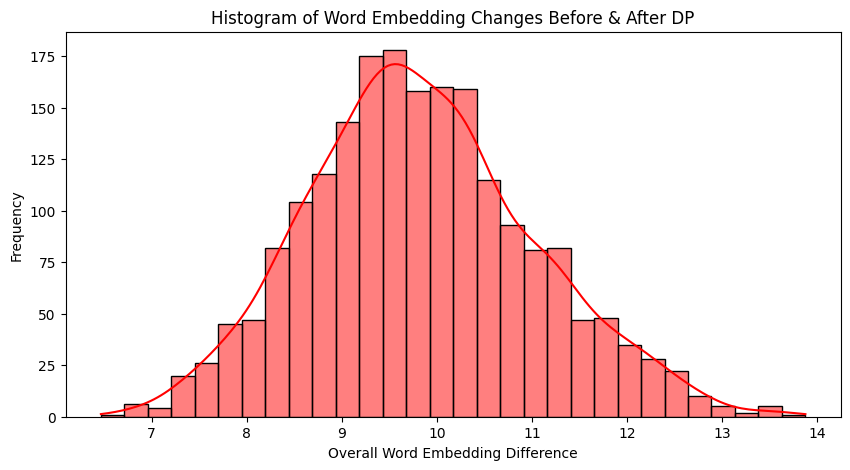

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.decomposition import PCA

# **STEP 1: Ensure PCA is Applied (50 Dimensions)**
pca = PCA(n_components=50, random_state=42)
original_pca = pca.fit_transform(np.vstack(df_squad["original_embedding"].to_numpy()))
dp_pca = pca.transform(np.vstack(df_squad["dp_embedding"].to_numpy()))

# **STEP 2: Apply UMAP for Dimensionality Reduction (2D)**
umap_reducer = umap.UMAP(n_components=2, random_state=42)
original_umap = umap_reducer.fit_transform(original_pca)
dp_umap = umap_reducer.transform(dp_pca)

# **Store UMAP Results in DataFrame**
df_squad['original_embedding_2d_x'] = original_umap[:, 0]
df_squad['original_embedding_2d_y'] = original_umap[:, 1]
df_squad['dp_embedding_2d_x'] = dp_umap[:, 0]
df_squad['dp_embedding_2d_y'] = dp_umap[:, 1]

# **STEP 3: Histogram for Changes in PCA Component 1**
df_squad["pca_component_1_diff"] = np.abs(original_pca[:, 0] - dp_pca[:, 0])

plt.figure(figsize=(10, 5))
sns.histplot(df_squad["pca_component_1_diff"], bins=30, kde=True, color="green")
plt.xlabel("Difference in PCA Component 1")
plt.ylabel("Frequency")
plt.title("Distribution of Changes in PCA Component 1 Before & After DP")
plt.show()

# **STEP 4: Histogram for Changes in UMAP Component 1**
df_squad["umap_component_1_diff"] = np.abs(original_umap[:, 0] - dp_umap[:, 0])

plt.figure(figsize=(10, 5))
sns.histplot(df_squad["umap_component_1_diff"], bins=30, kde=True, color="blue")
plt.xlabel("Difference in UMAP Component 1")
plt.ylabel("Frequency")
plt.title("Distribution of Changes in UMAP Component 1 Before & After DP")
plt.show()

# **STEP 5: Histogram for Overall Word Embedding Differences**
embedding_diff = np.linalg.norm(original_pca - dp_pca, axis=1)

plt.figure(figsize=(10, 5))
sns.histplot(embedding_diff, bins=30, kde=True, color="red")
plt.xlabel("Overall Word Embedding Difference")
plt.ylabel("Frequency")
plt.title("Histogram of Word Embedding Changes Before & After DP")
plt.show()


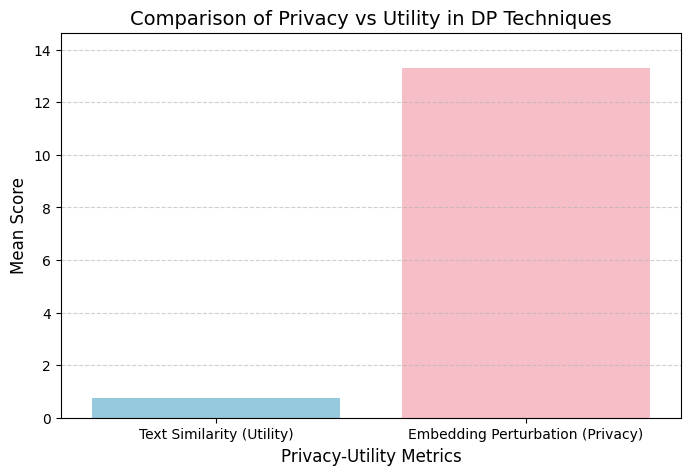

Privacy-Utility Data Table


,question,sanitized_question,dp_perturbation,original_embedding,dp_embedding,sentiment_score,dp_sentiment_score,deception_score,dp_deception_score,ner_sentiment_score,...,embedding_deception_score,num_changes,original_embedding_2d_x,original_embedding_2d_y,dp_embedding_2d_x,dp_embedding_2d_y,pca_component_1_diff,umap_component_1_diff,text_similarity,embedding_difference
0,To whom did the Virgin Mary allegedly appear i...,To whom did A Known Monument allegedly appear ...,To whom did a Known Monument allegedly appear ...,"[4.2535574699795875, 0.8515116104639358, 1.139...","[-0.24386067607259398, -0.3036780805959257, -3...",-0.100000,-0.100000,23.282,31.332,-0.05,...,55.482,2,5.052066,5.167095,2.817068,6.208861,2.326660,2.234998,0.926189,14.699005
1,What is in front of the Notre Dame Main Building?,What is in front of A Recognized Building?,What is in front of A Recognized Building ?,"[0.924346562517973, 0.6740273081278331, -0.346...","[-0.4233364464668097, 1.0703120866064717, -2.3...",0.166667,0.000000,3.381,13.804,0.00,...,55.482,1,5.562760,5.146726,2.052806,4.455418,1.599838,3.509954,1.000000,14.073230
2,The Basilica of the Sacred heart at Notre Dame...,The Basilica of the A Renowned Individual hear...,The Basilica of the A Renowned Individual core...,"[2.5201896611767847, -1.4216544610453306, -0.0...","[-0.6017307480100003, 0.5207479613970702, -0.1...",0.000000,0.000000,23.989,49.812,0.00,...,55.482,4,6.213731,2.888132,2.317050,5.879025,0.840619,3.896681,0.711564,13.360384
3,What is the Grotto at Notre Dame?,What is the Grotto at A Known Monument?,What live the Grotto at A Known Monument ?,"[-0.1965703428235106, -0.2577637296068309, -1....","[-0.46744853561935606, 1.9030779395661614, -0....",0.000000,0.136364,7.175,13.804,0.00,...,55.482,2,5.473526,5.671920,1.852799,4.577707,0.205223,3.620728,0.829069,14.981224
4,What sits on top of the Main Building at Notre...,What sits on top of A Recognized Building at A...,What sits on top of A Recognized Building at A...,"[-0.27964923660692054, -0.7672320171043912, -0...","[-0.15231593028163254, 0.3853957444984375, 0.3...",0.333333,0.500000,4.095,22.568,0.50,...,55.482,1,2.426100,5.010388,7.077945,3.936885,2.447537,4.651846,0.849133,13.527489


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Compute Text Similarity Using TF-IDF
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df_squad["sanitized_question"].tolist() + df_squad["dp_perturbation"].tolist())
tfidf_vectors = tfidf_matrix.toarray()

# Ensure valid vectors for similarity calculation
if len(tfidf_vectors) == 2 * len(df_squad):
    df_squad["text_similarity"] = [
        cosine_similarity([tfidf_vectors[i]], [tfidf_vectors[i + len(df_squad)]])[0, 0]
        for i in range(len(df_squad))
    ]
else:
    df_squad["text_similarity"] = np.nan

# Compute Embedding Perturbation Magnitude
df_squad["embedding_difference"] = np.linalg.norm(
    np.array(df_squad["original_embedding"].tolist()) - np.array(df_squad["dp_embedding"].tolist()), axis=1
)

# Create Privacy-Utility DataFrame
privacy_utility_data = pd.DataFrame({
    "Metric": ["Text Similarity (Utility)", "Embedding Perturbation (Privacy)"],
    "Score": [
        df_squad["text_similarity"].mean(),
        df_squad["embedding_difference"].mean()
    ]
})

# **Privacy-Utility Bar Graph**
plt.figure(figsize=(8, 5))
sns.barplot(x="Metric", y="Score", data=privacy_utility_data, palette=["skyblue", "lightpink"])

# Labels & Title
plt.xlabel("Privacy-Utility Metrics", fontsize=12)
plt.ylabel("Mean Score", fontsize=12)
plt.title("Comparison of Privacy vs Utility in DP Techniques", fontsize=14)

# Grid for Readability
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Adjust Y-Axis Limits Dynamically
plt.ylim(0, max(privacy_utility_data["Score"]) * 1.1)

plt.show()

# ✅ Create a DataFrame for Display
privacy_utility_df = df_squad[["sanitized_question", "dp_perturbation", "text_similarity", "embedding_difference"]].copy()

# ✅ Rename Columns for Better Readability
privacy_utility_df.columns = ["Original Text", "DP Perturbed Text", "Text Similarity (Utility)", "Embedding Difference (Privacy)"]


# Display First 5 Rows of Sentiment & Deception Score
import pandas as pd
from IPython.display import display

print("Privacy-Utility Data Table")
display(df_squad.head(5))  # Fixed for Google Colab/Jupyter


In [30]:
import pandas as pd
from IPython.display import display

# Create a DataFrame with Only 4 Required Columns
privacy_utility_df = df_squad[["sanitized_question", "dp_perturbation", "text_similarity", "embedding_difference"]].copy()

# Rename Columns for Better Readability
privacy_utility_df.columns = ["Original Text", "DP Perturbed Text", "Text Similarity (Utility)", "Embedding Difference (Privacy)"]

# Display First 5 Rows
print("Privacy-Utility Data Table")
display(privacy_utility_df.head(5))


Privacy-Utility Data Table


,Original Text,DP Perturbed Text,Text Similarity (Utility),Embedding Difference (Privacy)
0,To whom did A Known Monument allegedly appear ...,To whom did a Known Monument allegedly appear ...,0.926189,14.699005
1,What is in front of A Recognized Building?,What is in front of A Recognized Building ?,1.000000,14.073230
2,The Basilica of the A Renowned Individual hear...,The Basilica of the A Renowned Individual core...,0.711564,13.360384
3,What is the Grotto at A Known Monument?,What live the Grotto at A Known Monument ?,0.829069,14.981224
4,What sits on top of A Recognized Building at A...,What sits on top of A Recognized Building at A...,0.849133,13.527489
